# 中文新聞主題分類 — TF-IDF vs BERT 微調 (Colab)

自爬中央社 (CNA) 新聞，比較**傳統機器學習 (TF-IDF + 邏輯回歸)** 與 **預訓練語言模型 (BERT 微調)** 兩種方法。

> **執行前請先開 GPU**：上方選單 → 編輯 → 筆記本設定 → 硬體加速器選 **GPU**。
> 從上往下依序執行即可，全程使用 repo 內附的 973 篇資料集，幾分鐘內可跑完。

## 1. 安裝套件並 clone repo

In [7]:
!git -C /content/Nlp2026 pull

Already up to date.


In [8]:
!pip -q install jieba transformers
!git clone https://github.com/Upisofsht/Nlp2026.git
%cd Nlp2026/final_project
# 安裝中文字型，讓混淆矩陣的中文標籤正常顯示
!apt-get -qq install -y fonts-noto-cjk
import matplotlib.font_manager as fm
for _p in fm.findSystemFonts(fontpaths='/usr/share/fonts/opentype/noto'):
    fm.fontManager.addfont(_p)

Cloning into 'Nlp2026'...
remote: Enumerating objects: 145, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 145 (delta 74), reused 129 (delta 61), pack-reused 0 (from 0)
Receiving objects: 100% (145/145), 1.00 MiB | 14.47 MiB/s, done.
Resolving deltas: 100% (74/74), done.
/content/Nlp2026/final_project/Nlp2026/final_project


## 2. 資料來源：爬蟲（可選）

資料集已隨 repo 附上 (`data/news_dataset.csv`，共 973 篇)，**預設直接使用**，結果可重現。

下面這格示範爬蟲確實可跑：解除註解會用 CNA API 抓「科技」分類 3 篇（約幾秒），不影響後面流程。

In [9]:
from src.crawler import CATEGORIES, list_article_urls, parse_article, fetch

print('CNA 分類代碼 → 標籤：')
for code_, label in CATEGORIES.items():
    print(f'  {code_}: {label}')

# --- 想實際驗證爬蟲，解除以下註解（約幾秒）---
# urls = list_article_urls('ait', n_articles=3)
# for u in urls:
#     art = parse_article(fetch(u))
#     print('•', art['title'])

CNA 分類代碼 → 標籤：
  aipl: 政治
  aopl: 國際
  acn: 兩岸
  afe: 財經
  ait: 科技
  ahel: 生活
  asoc: 社會
  acul: 文化
  aspt: 體育
  amov: 娛樂


## 3. 載入資料 + 中文前處理（清理 → jieba 斷詞 → 去停用詞）

In [10]:
import sys, pandas as pd
sys.path.insert(0, '.')
from src.preprocess import tokenize, load_stopwords

df = pd.read_csv('data/news_dataset.csv')
df['text'] = df['title'].fillna('') + ' ' + df['content'].fillna('')

stop = load_stopwords('stopwords.txt')
# 給 TF-IDF 用：斷詞後用空白接成字串；BERT 直接吃原始 text，不需斷詞
df['tokens_str'] = df['text'].apply(lambda t: ' '.join(tokenize(t, stop)))

print('資料筆數：', len(df))
print(df['category'].value_counts())
df[['category', 'text', 'tokens_str']].head(3)

資料筆數： 973
category
娛樂    100
文化    100
社會    100
政治     99
生活     99
兩岸     99
體育     97
科技     95
國際     94
財經     90
Name: count, dtype: int64


,category,text,tokens_str
0,政治,女性家庭照顧者防災士專班開班 內政部盼成韌性力量 （中央社記者高華謙台北6日電）台灣婦女團體...,女性 家庭 照顧者 防災士 專班 開班 內政部 盼成 韌性 力量 中央社 記者 高華謙 台北...
1,政治,強化全社會防衛韌性 國防部將辦後備軍人射擊比賽 （中央社記者吳書緯台北6日電）為強化全社會防...,強化 全社 會防衛 韌性 國 防部 將辦後備 軍人射擊 比賽 中央社 記者 吳書緯 台北 6...
2,政治,健康台灣擴大篩檢 總統力拚2030年癌症死亡率降1/3 （中央社記者洪學廣高雄6日電）總統賴...,健康 台灣 擴大 篩檢 總統力 拚 2030 年 癌症 死亡率 降 13 中央社 記者 洪學...


## 4. 標籤編碼 + 切分 train / test（80 / 20，兩種方法共用同一切分）

In [11]:
from sklearn.model_selection import train_test_split

labels = sorted(df['category'].unique())
label2idx = {l: i for i, l in enumerate(labels)}
df['y'] = df['category'].map(label2idx)

tr, te = train_test_split(df, test_size=0.2, stratify=df['y'], random_state=42)
print('train', len(tr), '/ test', len(te), '/ 類別數', len(labels))

train 778 / test 195 / 類別數 10


## 5. 方法一：TF-IDF + 邏輯回歸（傳統機器學習）

用關鍵詞的 TF-IDF 權重當特徵，丟進邏輯回歸分類。簡單、訓練快、可解釋。

TF-IDF: acc=0.6974  macroF1=0.6842
              precision    recall  f1-score   support

          兩岸       0.89      0.80      0.84        20
          國際       0.75      0.47      0.58        19
          娛樂       0.83      0.75      0.79        20
          政治       0.62      0.80      0.70        20
          文化       0.78      0.90      0.84        20
          生活       0.65      0.75      0.70        20
          社會       0.79      0.75      0.77        20
          科技       0.75      0.79      0.77        19
          財經       0.07      0.06      0.06        18
          體育       0.76      0.84      0.80        19

    accuracy                           0.70       195
   macro avg       0.69      0.69      0.68       195
weighted avg       0.69      0.70      0.69       195



'confusion_baseline.png'

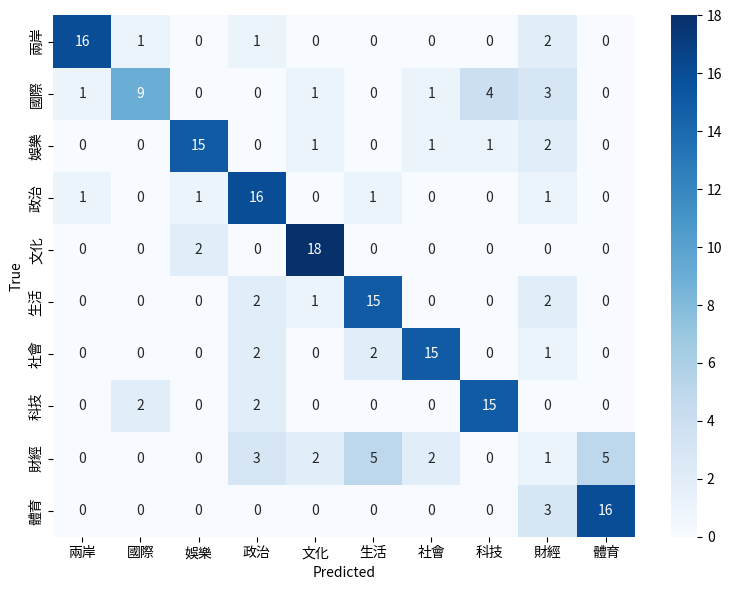

In [12]:
from src.features import build_tfidf
from src.models import train_baseline
from src.evaluate import evaluate_predictions, plot_confusion_matrix

X_tr, vec = build_tfidf(tr['tokens_str'])
X_te = vec.transform(te['tokens_str'])

clf = train_baseline(X_tr, tr['category'], kind='logreg')
tfidf_pred = clf.predict(X_te)

m_tfidf = evaluate_predictions(te['category'], tfidf_pred)
print('TF-IDF:', f"acc={m_tfidf['accuracy']:.4f}  macroF1={m_tfidf['macro_f1']:.4f}")
print(m_tfidf['report'])
plot_confusion_matrix(te['category'], tfidf_pred, labels, out_path='confusion_baseline.png')

## 6. 方法二：BERT 微調（預訓練語言模型）

用 `hfl/chinese-roberta-wwm-ext`，在 BERT 上接一層分類層，直接吃整篇新聞內文，不需斷詞。

In [13]:
import torch
from transformers import AutoTokenizer

MODEL_NAME = 'hfl/chinese-roberta-wwm-ext'
MAX_LEN = 256
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = list(labels)
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(self.texts[idx], truncation=True, padding='max_length',
                        max_length=MAX_LEN, return_tensors='pt')
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_ds = NewsDataset(tr['text'], tr['y'])
test_ds = NewsDataset(te['text'], te['y'])
print('train_ds', len(train_ds), '/ test_ds', len(test_ds))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/19.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/110k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/269k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

train_ds 778 / test_ds 195


### 微調訓練（3 epochs，需要 GPU，約幾分鐘）

In [14]:
from transformers import (AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(labels))

args = TrainingArguments(
    output_dir='bert_out',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    logging_steps=20,
    save_strategy='no',
    report_to='none',
)
trainer = Trainer(model=model, args=args, train_dataset=train_ds)
trainer.train()

pytorch_model.bin:   0%|          | 0.00/412M [00:00<?, ?B/s]

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/hfl/chinese-roberta-wwm-ext/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_convers

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: hfl/chinese-roberta-wwm-ext
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Step,Training Loss
20,2.189396
40,1.772456
60,1.438168
80,1.090060
100,0.973775
120,0.856552
140,0.777697


TrainOutput(global_step=147, training_loss=1.2749570794656975, metrics={'train_runtime': 105.6442, 'train_samples_per_second': 22.093, 'train_steps_per_second': 1.391, 'total_flos': 307072656672768.0, 'train_loss': 1.2749570794656975, 'epoch': 3.0})

## 7. BERT 評估 + 混淆矩陣

BERT: acc=0.7692  macroF1=0.7327
              precision    recall  f1-score   support

          兩岸       0.77      0.85      0.81        20
          國際       0.72      0.68      0.70        19
          娛樂       0.81      0.85      0.83        20
          政治       0.65      0.85      0.74        20
          文化       0.82      0.90      0.86        20
          生活       0.69      0.90      0.78        20
          社會       0.94      0.85      0.89        20
          科技       0.81      0.68      0.74        19
          財經       1.00      0.06      0.11        18
          體育       0.76      1.00      0.86        19

    accuracy                           0.77       195
   macro avg       0.80      0.76      0.73       195
weighted avg       0.80      0.77      0.74       195



'confusion_bert.png'

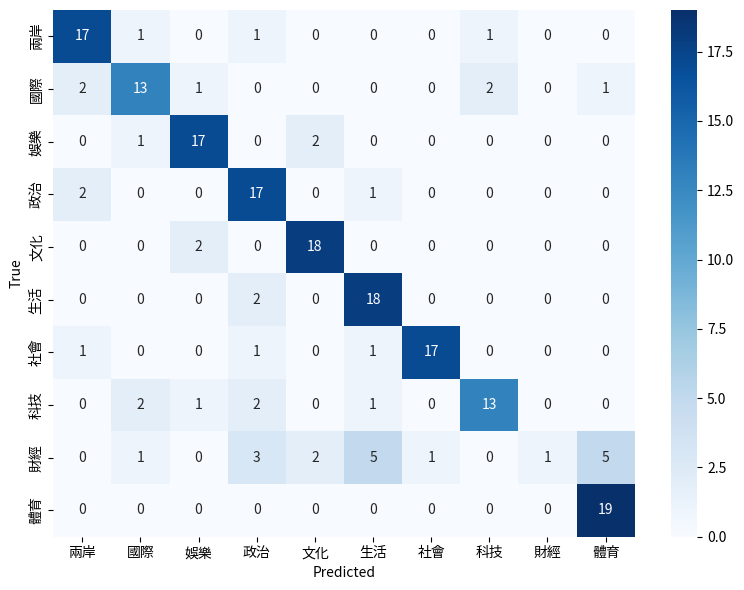

In [15]:
pred_logits = trainer.predict(test_ds).predictions
pred_idx = pred_logits.argmax(axis=1)
bert_pred = [labels[i] for i in pred_idx]
bert_true = [labels[i] for i in te['y']]

m_bert = evaluate_predictions(bert_true, bert_pred)
print('BERT:', f"acc={m_bert['accuracy']:.4f}  macroF1={m_bert['macro_f1']:.4f}")
print(m_bert['report'])
plot_confusion_matrix(bert_true, bert_pred, labels, out_path='confusion_bert.png')

## 8. 結果比較

同一份 973 篇資料、同樣 80/20 切分，兩種方法的成績比較。

In [16]:
summary = pd.DataFrame([
    {'方法': 'TF-IDF + 邏輯回歸', 'Accuracy': round(m_tfidf['accuracy'], 4),
     'Macro-F1': round(m_tfidf['macro_f1'], 4)},
    {'方法': 'BERT 微調', 'Accuracy': round(m_bert['accuracy'], 4),
     'Macro-F1': round(m_bert['macro_f1'], 4)},
])
print(summary.to_string(index=False))
print()
print('觀察：BERT 明顯優於 TF-IDF baseline；但兩者對「財經」皆難分類')
print('原因：財經用詞與科技／政治／兩岸高度重疊，屬類別語意重疊的典型混淆')
summary

           方法  Accuracy  Macro-F1
TF-IDF + 邏輯回歸    0.6974    0.6842
      BERT 微調    0.7692    0.7327

觀察：BERT 明顯優於 TF-IDF baseline；但兩者對「財經」皆難分類
原因：財經用詞與科技／政治／兩岸高度重疊，屬類別語意重疊的典型混淆


,方法,Accuracy,Macro-F1
0,TF-IDF + 邏輯回歸,0.6974,0.6842
1,BERT 微調,0.7692,0.7327
